# Job Recommendation and Candidate Matching Using Content-Based Filtering and Cosine Similarity

## Mini Hackathon 1

This project recommends relevant job opportunities by comparing a candidate profile with job postings using TF-IDF and Cosine Similarity.

# 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("jobs.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 Records:")
display(df.head())

Dataset Shape: (1167, 5)

Columns:
Index(['job_id', 'category', 'job_title', 'job_description', 'job_skill_set'], dtype='object')

First 5 Records:


,job_id,category,job_title,job_description,job_skill_set
0,3902668440,HR,Sr Human Resource Generalist,SUMMARY\nTHE SR. HR GENERALIST PROVIDES HR EXP...,"['employee relations', 'talent acquisition', '..."
1,3905823748,HR,Human Resources Manager,BE PART OF A STELLAR TEAM AT YSB AS THE MANAGE...,"['Talent Acquisition', 'Employee Performance M..."
2,3905854799,HR,Director of Human Resources,OUR CLIENT IS A THRIVING ORGANIZATION OFFERING...,"['Human Resources Management', 'Recruitment', ..."
3,3905834061,HR,Chief Human Resources Officer,JOB TITLE: CHIEF HUMAN RESOURCES OFFICER (CHRO...,"['talent management', 'organizational developm..."
4,3906250451,HR,Human Resources Generalist (Hybrid Role),DESCRIPTION\n\n WHO WE ARE \n\nAVI-SPL IS A DI...,"['Microsoft Office', 'Data analysis', 'Employe..."


# 2. Dataset Overview and Data Quality

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1167 entries, 0 to 1166
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_id           1167 non-null   int64 
 1   category         1167 non-null   object
 2   job_title        1167 non-null   object
 3   job_description  1167 non-null   object
 4   job_skill_set    1167 non-null   object
dtypes: int64(1), object(4)
memory usage: 45.7+ KB


In [4]:
print(df.isnull().sum())

job_id             0
category           0
job_title          0
job_description    0
job_skill_set      0
dtype: int64


In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## 3. Exploratory Data Analysis (EDA)

In [6]:
category_counts = df["category"].value_counts()

print(category_counts)

category
INFORMATION-TECHNOLOGY    240
BUSINESS-DEVELOPMENT      239
FINANCE                   236
SALES                     232
HR                        220
Name: count, dtype: int64


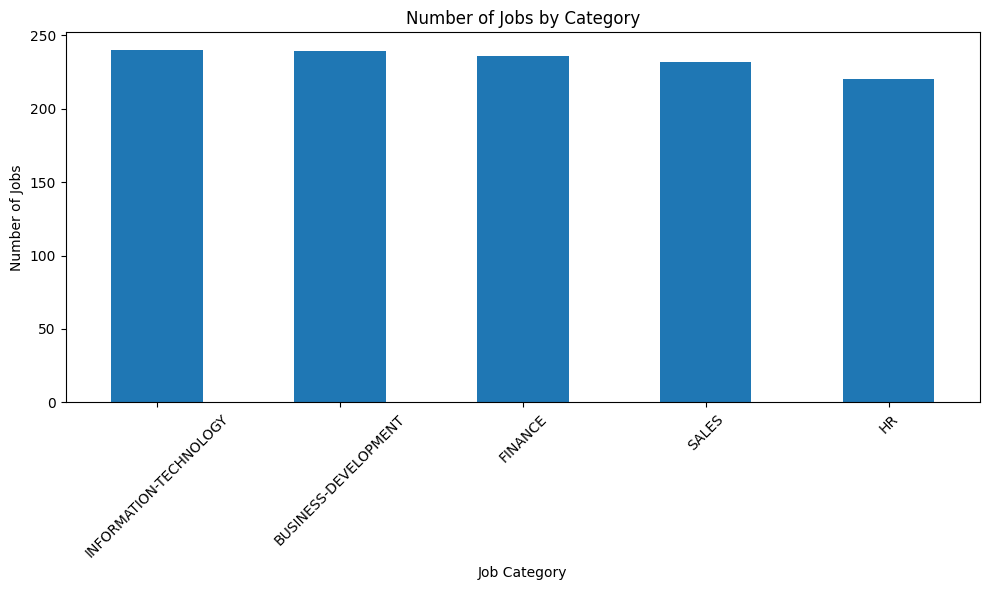

In [7]:
plt.figure(figsize=(10, 6))
category_counts.plot(kind="bar")
plt.title("Number of Jobs by Category")
plt.xlabel("Job Category")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
top_titles = df["job_title"].value_counts().head(10)

print(top_titles)

job_title
Business Development Manager                 53
Human Resources Generalist                   34
Business Development Representative          33
Human Resources Manager                      28
Information Technology Support Specialist    16
Finance Manager                              15
Human Resources Business Partner             15
Director of Finance                          13
Human Resources Coordinator                  11
Information Technology Project Manager       11
Name: count, dtype: int64


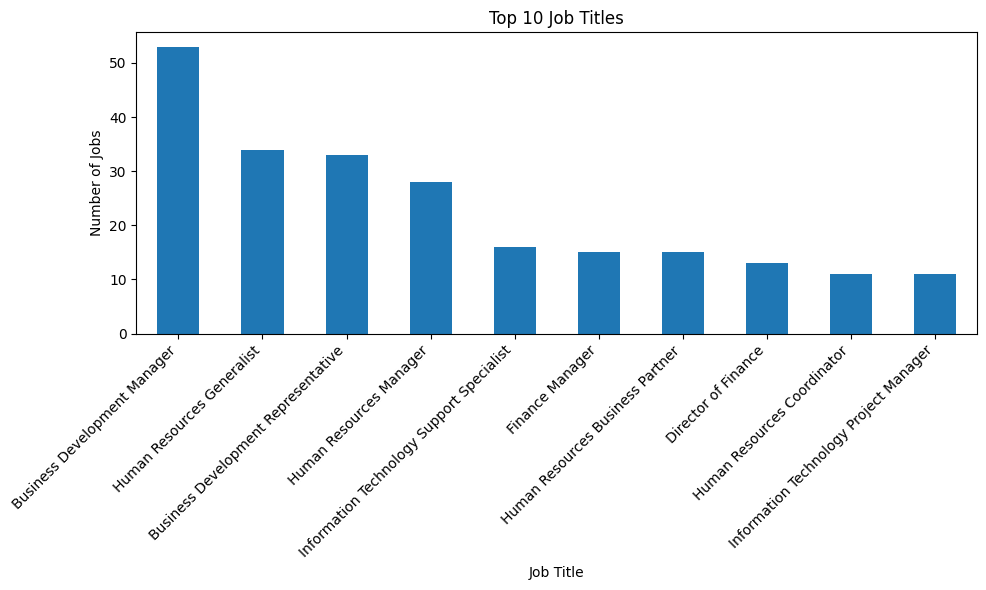

In [9]:
plt.figure(figsize=(10, 6))

top_titles.plot(kind="bar")

plt.title("Top 10 Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [11]:
import ast

df["skills"] = df["job_skill_set"].apply(ast.literal_eval)

In [12]:
print(df["skills"].head())

0    [employee relations, talent acquisition, perfo...
1    [Talent Acquisition, Employee Performance Mana...
2    [Human Resources Management, Recruitment, Empl...
3    [talent management, organizational development...
4    [Microsoft Office, Data analysis, Employee onb...
Name: skills, dtype: object


In [13]:
from collections import Counter

all_skills = []

for skills in df["skills"]:
    all_skills.extend([skill.lower().strip() for skill in skills])

skill_counts = Counter(all_skills)

print(skill_counts.most_common(20))

[('communication', 1092), ('problem solving', 878), ('adaptability', 588), ('teamwork', 569), ('collaboration', 341), ('leadership', 325), ('time management', 316), ('interpersonal skills', 288), ('customer service', 272), ('relationship building', 267), ('attention to detail', 253), ('data analysis', 251), ('project management', 234), ('organizational skills', 231), ('negotiation', 157), ('sales', 148), ('presentation skills', 144), ('business development', 137), ('financial analysis', 131), ('strategic thinking', 127)]


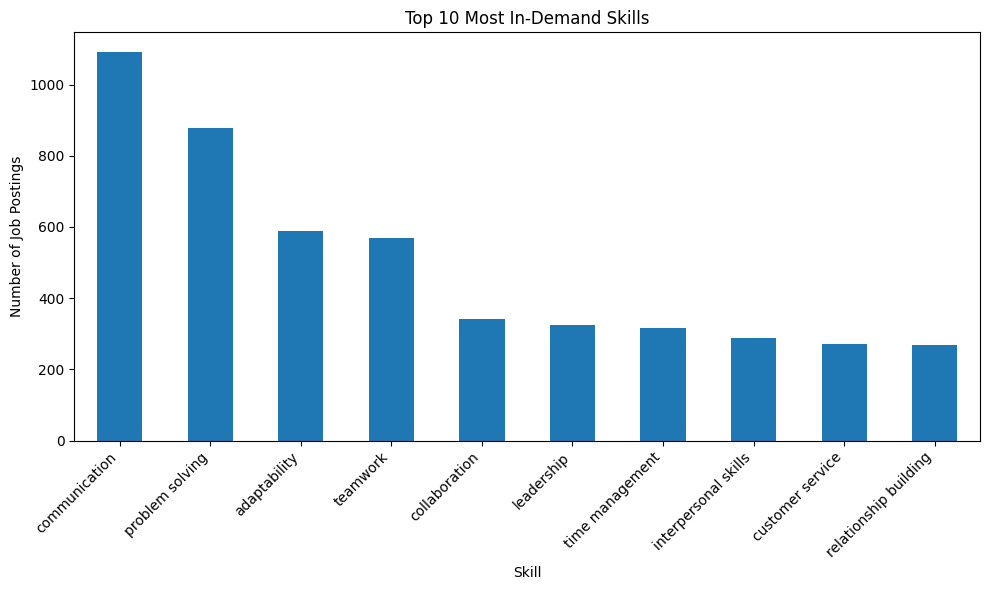

In [14]:
top_skills = pd.Series(
    dict(skill_counts.most_common(10))
)

plt.figure(figsize=(10, 6))

top_skills.plot(kind="bar")

plt.title("Top 10 Most In-Demand Skills")
plt.xlabel("Skill")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [15]:
df["description_length"] = df["job_description"].str.len()

print(df["description_length"].describe())

count     1167.000000
mean      3768.315338
std       2103.065595
min        167.000000
25%       2124.000000
50%       3445.000000
75%       4932.500000
max      13639.000000
Name: description_length, dtype: float64


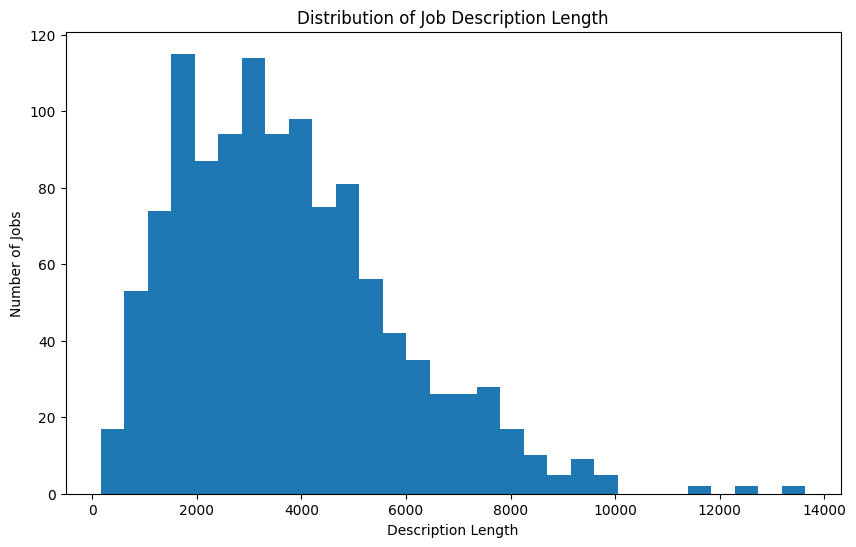

In [16]:
plt.figure(figsize=(10, 6))

plt.hist(df["description_length"], bins=30)

plt.title("Distribution of Job Description Length")
plt.xlabel("Description Length")
plt.ylabel("Number of Jobs")

plt.show()

## 4. Text Preprocessing

In [17]:
df["job_text"] = (
    df["job_title"].fillna("") + " " +
    df["job_description"].fillna("") + " " +
    df["job_skill_set"].fillna("")
)

print(df[["job_title", "job_text"]].head())

                                  job_title  \
0              Sr Human Resource Generalist   
1                   Human Resources Manager   
2               Director of Human Resources   
3             Chief Human Resources Officer   
4  Human Resources Generalist (Hybrid Role)   

                                            job_text  
0  Sr Human Resource Generalist SUMMARY\nTHE SR. ...  
1  Human Resources Manager BE PART OF A STELLAR T...  
2  Director of Human Resources OUR CLIENT IS A TH...  
3  Chief Human Resources Officer JOB TITLE: CHIEF...  
4  Human Resources Generalist (Hybrid Role) DESCR...  


In [18]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["clean_job_text"] = df["job_text"].apply(clean_text)

print(df[["job_text", "clean_job_text"]].head())

                                            job_text  \
0  Sr Human Resource Generalist SUMMARY\nTHE SR. ...   
1  Human Resources Manager BE PART OF A STELLAR T...   
2  Director of Human Resources OUR CLIENT IS A TH...   
3  Chief Human Resources Officer JOB TITLE: CHIEF...   
4  Human Resources Generalist (Hybrid Role) DESCR...   

                                      clean_job_text  
0  sr human resource generalist summary the sr hr...  
1  human resources manager be part of a stellar t...  
2  director of human resources our client is a th...  
3  chief human resources officer job title chief ...  
4  human resources generalist hybrid role descrip...  


## 5. TF-IDF Vectorization

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer(stop_words="english")

# Convert job text into numerical vectors
job_vectors = vectorizer.fit_transform(df["clean_job_text"])

print("Number of jobs:", job_vectors.shape[0])
print("Number of features:", job_vectors.shape[1])

Number of jobs: 1167
Number of features: 21010


## 6. Candidate Profile and Cosine Similarity

In [20]:
candidate_profile = """
Python
Machine Learning
SQL
Pandas
Data Analysis
Artificial Intelligence
"""

print(candidate_profile)


Python
Machine Learning
SQL
Pandas
Data Analysis
Artificial Intelligence



In [21]:
candidate_vector = vectorizer.transform([candidate_profile])

print("Candidate vector shape:", candidate_vector.shape)

Candidate vector shape: (1, 21010)


In [22]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_scores = cosine_similarity(
    candidate_vector,
    job_vectors
).flatten()

print("Number of similarity scores:", len(similarity_scores))

Number of similarity scores: 1167


In [23]:
df["similarity_score"] = similarity_scores

print(df[["job_title", "similarity_score"]].head())

                                  job_title  similarity_score
0              Sr Human Resource Generalist          0.018575
1                   Human Resources Manager          0.000000
2               Director of Human Resources          0.005901
3             Chief Human Resources Officer          0.005214
4  Human Resources Generalist (Hybrid Role)          0.011867


In [24]:
recommendations = df.sort_values(
    by="similarity_score",
    ascending=False
)

## 7. Job Recommendations

In [25]:
top_jobs = recommendations[
    ["job_title", "category", "similarity_score"]
].head(10)

print(top_jobs)

                                             job_title  \
832  VP / Client, Finance & Strategy Data Scientist...   
293                  Information Technology Specialist   
831  Data Solutions Analyst II (Managed Care - Fina...   
372                  Information Technology Specialist   
897          Lead Software Engineer - Finance (Hybrid)   
321                  Information Technology Programmer   
237          Information Technology Support Technician   
219  Data Engineer - Enterprise Data and Analytics,...   
757  Staff Data Engineer - People & Finance Tech (R...   
382         Information Technology Application Manager   

                   category  similarity_score  
832                 FINANCE          0.179365  
293  INFORMATION-TECHNOLOGY          0.166276  
831                 FINANCE          0.150216  
372  INFORMATION-TECHNOLOGY          0.147119  
897                 FINANCE          0.145921  
321  INFORMATION-TECHNOLOGY          0.125938  
237  INFORMATION-TECHNOLO

In [26]:
top_jobs = top_jobs.copy()

top_jobs["match_percentage"] = (
    top_jobs["similarity_score"] * 100
)

print(
    top_jobs[
        ["job_title", "category", "match_percentage"]
    ]
)

                                             job_title  \
832  VP / Client, Finance & Strategy Data Scientist...   
293                  Information Technology Specialist   
831  Data Solutions Analyst II (Managed Care - Fina...   
372                  Information Technology Specialist   
897          Lead Software Engineer - Finance (Hybrid)   
321                  Information Technology Programmer   
237          Information Technology Support Technician   
219  Data Engineer - Enterprise Data and Analytics,...   
757  Staff Data Engineer - People & Finance Tech (R...   
382         Information Technology Application Manager   

                   category  match_percentage  
832                 FINANCE         17.936543  
293  INFORMATION-TECHNOLOGY         16.627552  
831                 FINANCE         15.021604  
372  INFORMATION-TECHNOLOGY         14.711887  
897                 FINANCE         14.592117  
321  INFORMATION-TECHNOLOGY         12.593839  
237  INFORMATION-TECHNOLO

In [28]:
candidate_vector = vectorizer.transform([candidate_profile])
print(candidate_vector.shape)

(1, 21010)


In [29]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_scores = cosine_similarity(
    candidate_vector,
    job_vectors
).flatten()

print(len(similarity_scores))

1167


In [30]:
df["similarity_score"] = similarity_scores

recommendations = df.sort_values(
    by="similarity_score",
    ascending=False
)

top_jobs = recommendations[
    ["job_title", "category", "similarity_score"]
].head(10)

print(top_jobs)

                                             job_title  \
832  VP / Client, Finance & Strategy Data Scientist...   
293                  Information Technology Specialist   
831  Data Solutions Analyst II (Managed Care - Fina...   
372                  Information Technology Specialist   
897          Lead Software Engineer - Finance (Hybrid)   
321                  Information Technology Programmer   
237          Information Technology Support Technician   
219  Data Engineer - Enterprise Data and Analytics,...   
757  Staff Data Engineer - People & Finance Tech (R...   
382         Information Technology Application Manager   

                   category  similarity_score  
832                 FINANCE          0.179365  
293  INFORMATION-TECHNOLOGY          0.166276  
831                 FINANCE          0.150216  
372  INFORMATION-TECHNOLOGY          0.147119  
897                 FINANCE          0.145921  
321  INFORMATION-TECHNOLOGY          0.125938  
237  INFORMATION-TECHNOLO

In [31]:
top_jobs = top_jobs.copy()

top_jobs["match_percentage"] = (
    top_jobs["similarity_score"] * 100
)

print(
    top_jobs[
        ["job_title", "category", "match_percentage"]
    ]
)

                                             job_title  \
832  VP / Client, Finance & Strategy Data Scientist...   
293                  Information Technology Specialist   
831  Data Solutions Analyst II (Managed Care - Fina...   
372                  Information Technology Specialist   
897          Lead Software Engineer - Finance (Hybrid)   
321                  Information Technology Programmer   
237          Information Technology Support Technician   
219  Data Engineer - Enterprise Data and Analytics,...   
757  Staff Data Engineer - People & Finance Tech (R...   
382         Information Technology Application Manager   

                   category  match_percentage  
832                 FINANCE         17.936543  
293  INFORMATION-TECHNOLOGY         16.627552  
831                 FINANCE         15.021604  
372  INFORMATION-TECHNOLOGY         14.711887  
897                 FINANCE         14.592117  
321  INFORMATION-TECHNOLOGY         12.593839  
237  INFORMATION-TECHNOLO